## I chose problem A becuase solving for multiple inputs seemed interesting.

$
\frac{dV_c}{dt} = \frac{V_{\text{in}}(t) - V_c}{RC}
$

$
V_{\text{in}}(t) = A_0 \sin(2\pi f t)
$


Amplitude ratio 0.9882200332628738 for frequency 50 Hz
Amplitude ratio 0.9718078719570467 for frequency 100 Hz
Amplitude ratio 0.9499273642730309 for frequency 150 Hz
Amplitude ratio 0.7907849945212703 for frequency 200 Hz
Amplitude ratio 0.7682248702080415 for frequency 250 Hz


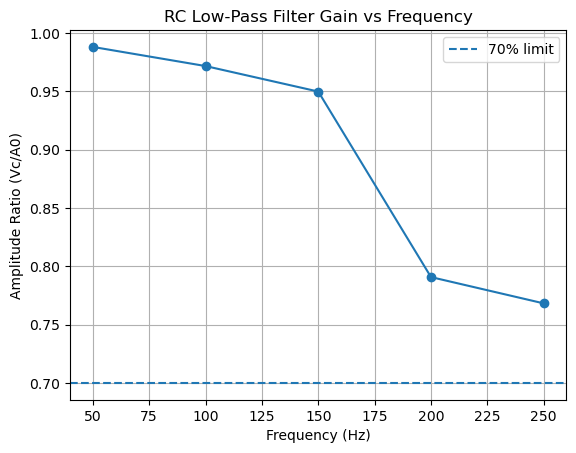

In [13]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#define both Vin function and ODE
def Vin(t, A0=1.0, f=50):
    return A0 * np.sin(2 * np.pi * f * t)
def dVc_dt(t, Vc, R, C, V_in_func):
    return (V_in_func(t) - Vc) / (R * C)

#define initial values
A0 = 1
R = 500  
C = 0.7e-6  
frequencies = [50, 100, 150, 200, 250]
t_span = (0, 1) #time span
Vc0 = [0] #initial capacitor voltage at t=0
t_eval = np.arange(0, 1.0, 0.001) #(start time, end time, step time)

amp_ratios = [] #for plot
freq_list = []


for freq in frequencies:
    V_in_func = lambda t: Vin(t, A0=1.0, f=freq) #freeze amplitude and freq values through many t

    solution = solve_ivp(
        fun = lambda t, Vc: dVc_dt(t, Vc, R, C, V_in_func),  # ODE function
        t_span = t_span,     # start and end time
        y0 = Vc0,            # initial capacitor voltage
        t_eval = t_eval      # times at which to store Vc(t)
    )

    Vc = solution.y[0] 
    time = solution.t
    
    steady_state_Vc = Vc[int(0.75*len(Vc)):] #looks at last part of sim
    Vc_amp = np.max(steady_state_Vc)
    ampRatio = Vc_amp/A0
    print("Amplitude ratio", ampRatio, "for frequency", freq, "Hz")

    amp_ratios.append(ampRatio)
    freq_list.append(freq)
    
plt.figure()
plt.plot(freq_list, amp_ratios, marker='o')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude Ratio (Vc/A0)")
plt.title("RC Low-Pass Filter Gain vs Frequency")
plt.axhline(0.70, linestyle='--', label="70% limit")
plt.legend()
plt.grid(True)
plt.show()


## Results Summary

For the resistor, I chose a value of 500 Ω, and for the capacitor, I selected 0.7 µF. I chose these values because reducing either R or C decreases the time constant RC. A smaller time constant increases the cutoff frequency of the RC filter. By choosing lower values than the common 1000 Ω and 1 µF, the filter’s cutoff frequency shifts higher, resulting in less attenuation and allowing frequencies up to 250 Hz to pass with an amplitude ratio above 70%.
